In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import (
    plot_grid,
    plot_with_bands,
    plot_heatmap,
    plot_scatter_markers,
)
import ast
import numpy as np
from functools import partial
import re

In [2]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(rcparams)

In [3]:
linestyles = {
    "RV": "-",
    "DC": "--",
    "QAP": "-.",
    "CVM": ":",
}

colors = {
    "DC": "#4285F4",  # Blue
    # "CCA": "#EA4335",  # Red
    "AC_1": "#EA4335",  # Dark Green
    "AC_sqrt": "#6AA84F",  # Light Green
    "AC_adaptive": "#673AB7",  # Purple
    "RVTest_permutation": "#FF9800",  # Light Orange
    "RVTest_asymptotic": "#FBBC05",  # Yellow
}

marker_map = {"DC": "x", "CCA": "o", "AC_1": "D", "AC_sqrt": "D", "AC_adaptive": "D", 
              "RVTest_permutation": "v", "RVTest_asymptotic": "v"}

In [4]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [5]:
results_functionals = pd.read_csv("simulation_results_20260723_1155.csv")
results_functionals2 = pd.read_csv("simulation_results_20260726_0339.csv")

results_latent_sim = pd.read_csv("simulation_results_20260723_1322.csv")
results_latent_sim2 = pd.read_csv("simulation_results_20260726_0342.csv")

# results_sbm = pd.read_csv("simulation_results_20260708_0908.csv")

results_gaussian = pd.read_csv("simulation_results_20260723_1332.csv")
results_gaussian2 = pd.read_csv("simulation_results_20260726_0347.csv")

results_bernoulli = pd.read_csv("simulation_results_20260723_1407.csv")
results_bernoulli2 = pd.read_csv("simulation_results_20260726_0353.csv")

results_null = pd.read_csv("simulation_results_20260723_1554.csv")
results_null2 = pd.read_csv("simulation_results_20260726_0400.csv")

In [6]:
results_concat = pd.concat([results_gaussian, results_bernoulli, results_functionals, results_latent_sim, results_null])
results_concat2 = pd.concat([results_gaussian2, results_bernoulli2, results_functionals2, results_latent_sim2, results_null2])

In [7]:
from results.results_processing import process_results

results_all = process_results(results_concat)

results_all2 = process_results(results_concat2)

/Users/lrcosta/umich/testing-network-independence/results/results_processing.py:628: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result.loc[missing, column] = NA_VALUE
/Users/lrcosta/umich/testing-network-independence/results/results_processing.py:628: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result.loc[missing, column] = NA_VALUE


In [8]:
from collections.abc import Mapping
import numpy as np
import pandas as pd


columns_to_replace = [
    "RelativeFrobeniusNorm_x",
    "RelativeFrobeniusNorm_z",
    "ProcrustesDistance_x",
    "ProcrustesDistance_z",
    "FalseRejection",
    "Power",
    "Rejection",
    "avg_rel_frob_z",
    "avg_proc_dist_z",
]

columns_to_match = [
    "density",
    "n",
    "k",
    "edge_var",
    "approximation",
    "solver",
    "rho",
    "method",
    "marginals",
    "density_A",
    "density_B",
    "make_sparse",
    "use_true_x",
    "use_true_z",
    "latent_sim",
    "aggregate",
    "copula",
    "marginal_y",
    "marginal_z",
    "degree",
    "NN_number",
    "functional_form",
    "sbm_covariate_sampling",
    "assortativity",
    "x_distribution",
    "adaptive_m",
    "column_covariance",
    "dgp_name",
    "column_covariance_type",
    "column_covariance_condition_number",
]


def make_comparable(value):
    if isinstance(value, np.generic):
        value = value.item()

    if isinstance(value, np.ndarray):
        return ("array", make_comparable(value.tolist()))

    if isinstance(value, Mapping):
        items = (
            (make_comparable(key), make_comparable(item))
            for key, item in value.items()
        )
        return ("dict", tuple(sorted(items, key=repr)))

    if isinstance(value, (list, tuple)):
        return (
            "sequence",
            tuple(make_comparable(item) for item in value),
        )

    try:
        if pd.isna(value):
            return ("missing",)
    except (TypeError, ValueError):
        pass

    return value


def make_row_keys(frame):
    return frame[columns_to_match].apply(
        lambda row: tuple(
            make_comparable(value) for value in row
        ),
        axis=1,
    )


method = "RVTest_asymptotic"

target_positions = np.flatnonzero(
    results_all["method"].eq(method).to_numpy()
)
source_positions = np.flatnonzero(
    results_all2["method"].eq(method).to_numpy()
)

target = results_all.iloc[target_positions].copy()
source = results_all2.iloc[source_positions].copy()

target["_position"] = target_positions
source["_position"] = source_positions

target["_key"] = make_row_keys(target)
source["_key"] = make_row_keys(source)

# Distinguish repeated runs with the same configuration.
target["_occurrence"] = target.groupby(
    "_key", sort=False
).cumcount()

source["_occurrence"] = source.groupby(
    "_key", sort=False
).cumcount()

matches = target[
    ["_position", "_key", "_occurrence"]
].merge(
    source[["_position", "_key", "_occurrence"]],
    on=["_key", "_occurrence"],
    how="inner",
    suffixes=("_target", "_source"),
    validate="one_to_one",
)

print(f"Matched rows: {len(matches)}")
print(f"Old unmatched rows: {len(target) - len(matches)}")
print(f"New unmatched rows: {len(source) - len(matches)}")

assert len(matches) == 47_400, (
    f"Expected 47,400 matching rows, found {len(matches)}"
)

# Keep a backup before modifying results_all.
results_all_before_swap = results_all.copy()

target_column_positions = results_all.columns.get_indexer(
    columns_to_replace
)
source_column_positions = results_all2.columns.get_indexer(
    columns_to_replace
)

results_all.iloc[
    matches["_position_target"].to_numpy(),
    target_column_positions,
] = results_all2.iloc[
    matches["_position_source"].to_numpy(),
    source_column_positions,
].to_numpy()

print("Replacement completed.")

Matched rows: 47400
Old unmatched rows: 7200
New unmatched rows: 7200
Replacement completed.


### Defining different aggregations

In [9]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [10]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_gaussian = results_gaussian[(results_gaussian["rho"] != 0.0)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_bernoulli = results_bernoulli[(results_bernoulli["rho"] != 0)].copy()

## Type I error

**Ensure type I error is controlled at 5%**

In [11]:
agg_null_gaussian = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["method", "copula", "marginal_z", "marginal_y", "column_covariance_condition_number"],
)

agg_null_bernoulli = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["method", "copula", "marginal_z", "marginal_y", "column_covariance_condition_number"],
)

# agg_null_gaussian_frob = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_frob = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )

# agg_null_gaussian_proc = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_proc = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )

In [12]:
rcparams = {
    "text.usetex": False,  # Disabled LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.weight": "normal",  # Bolds all general text
    "font.size": 17,
    "figure.titlesize": 17,
    "figure.titleweight": "normal",  # Bolds the main figure title
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.labelweight": "normal",  # Bolds axis labels (x, y)
    "axes.titleweight": "normal",  # Bolds axis titles
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

plt.rcParams.update(rcparams)

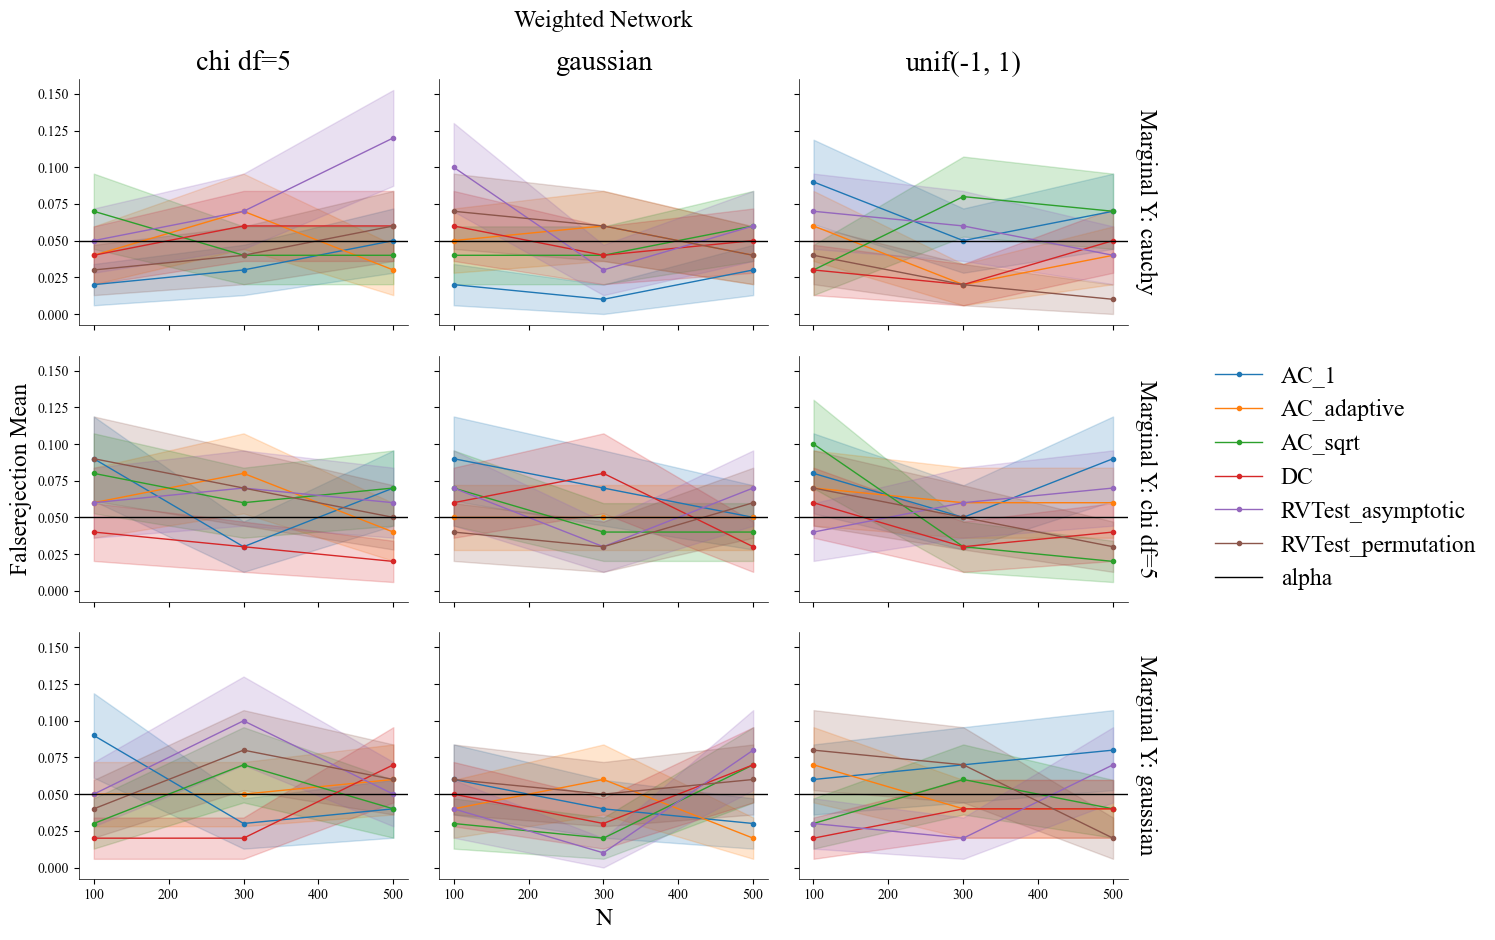

In [13]:
temp = agg_null_gaussian.copy()
temp = temp[temp["column_covariance_condition_number"] == 1 ].copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginal_z", "marginal_y"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network",
    hline=0.05,
    hline_name="alpha",
    show_row_titles=True,
    show_row_names=True,
    show_col_names=False,
    #col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

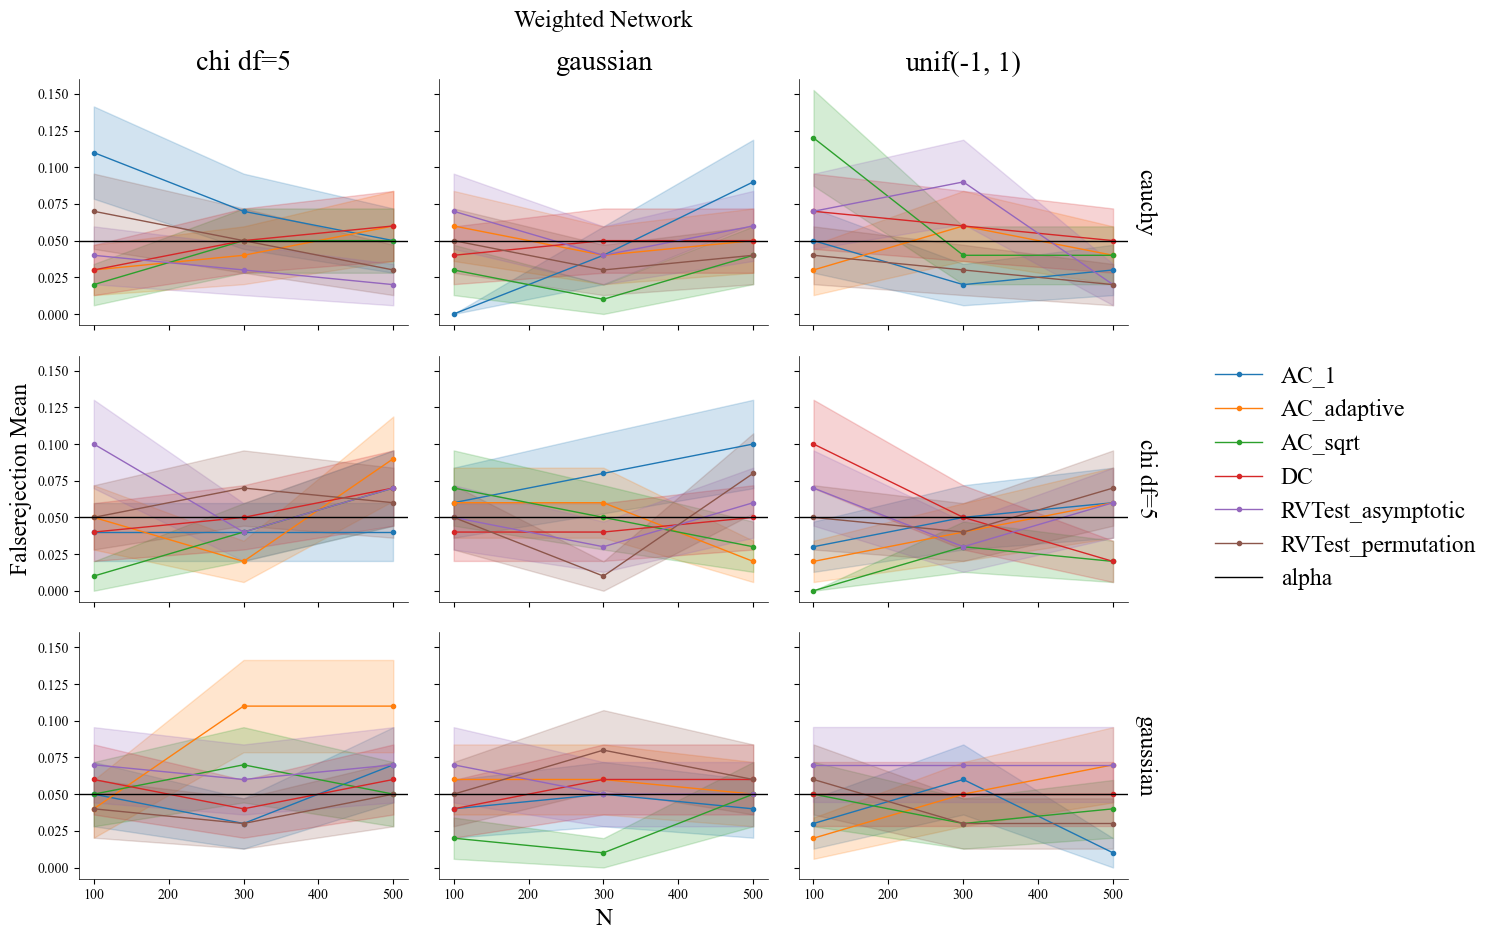

In [14]:
temp = agg_null_bernoulli.copy()
temp = temp[temp["column_covariance_condition_number"] == 1 ].copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginal_z", "marginal_y"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network",
    hline=0.05,
    hline_name="alpha",
    show_row_titles=True,
    show_row_names=False,
    show_col_names=False,
    #col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

### Power

In [15]:
agg_alt_gaussian = aggregate_results(
    results_alt_gaussian,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginal_y", "marginal_z", "method", "latent_sim", "make_sparse", "functional_form", "copula", "sbm_covariate_sampling", "assortativity", "x_distribution"],
)

agg_alt_bernoulli = aggregate_results(
    results_alt_bernoulli,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginal_y", "marginal_z", "method", "latent_sim", "make_sparse", "functional_form", "copula", "sbm_covariate_sampling", "assortativity", "x_distribution"],
)

In [16]:
copulas = ['gaussian', 'student_t', 'clayton', 'mixture']
marginals_z = ['gaussian', 'chi df=5']
marginals_y = ['gaussian', 'chi df=5', 'cauchy']

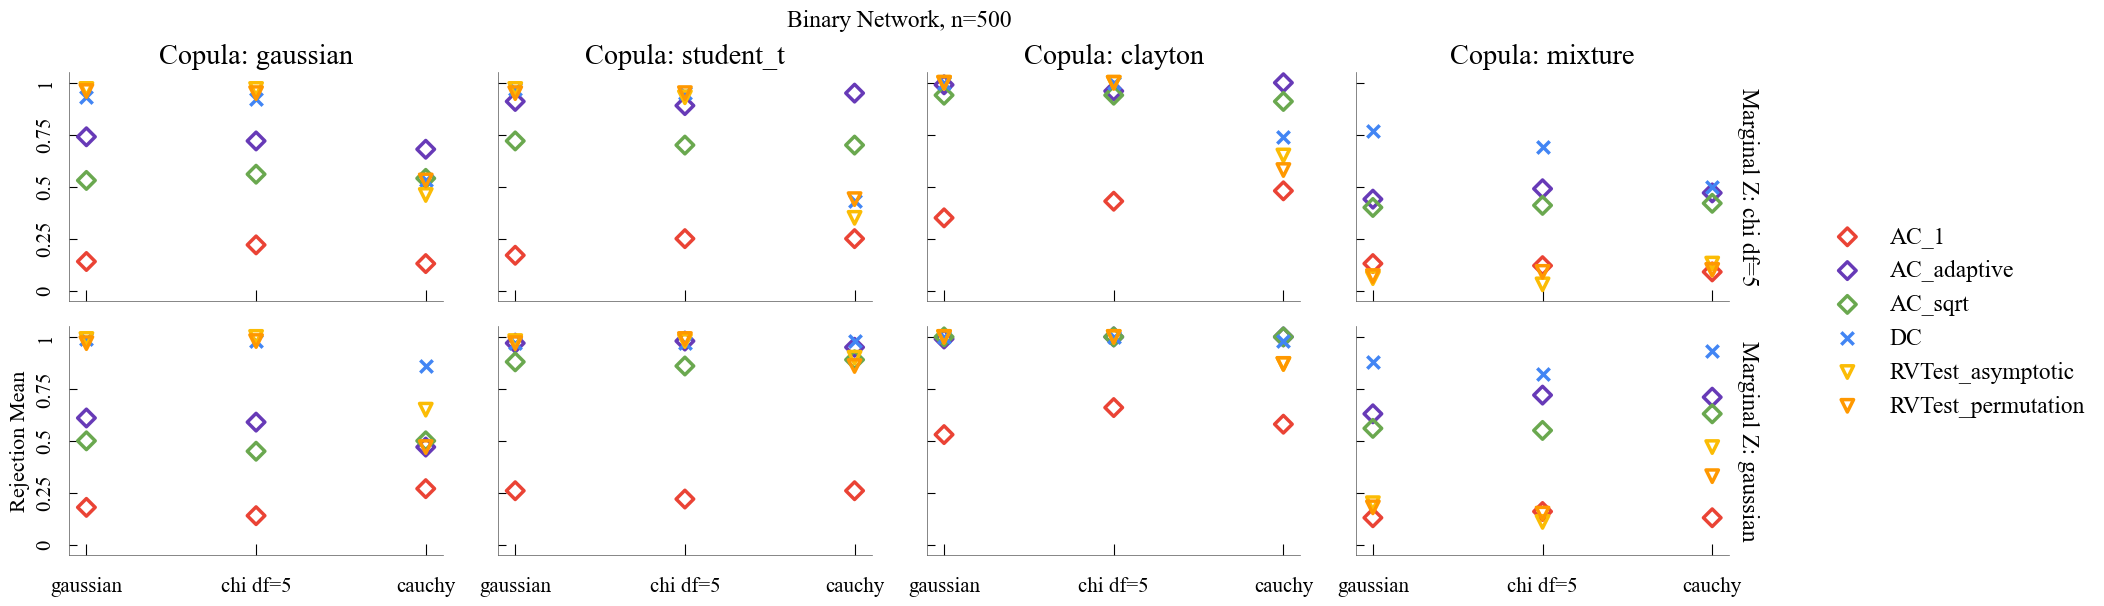

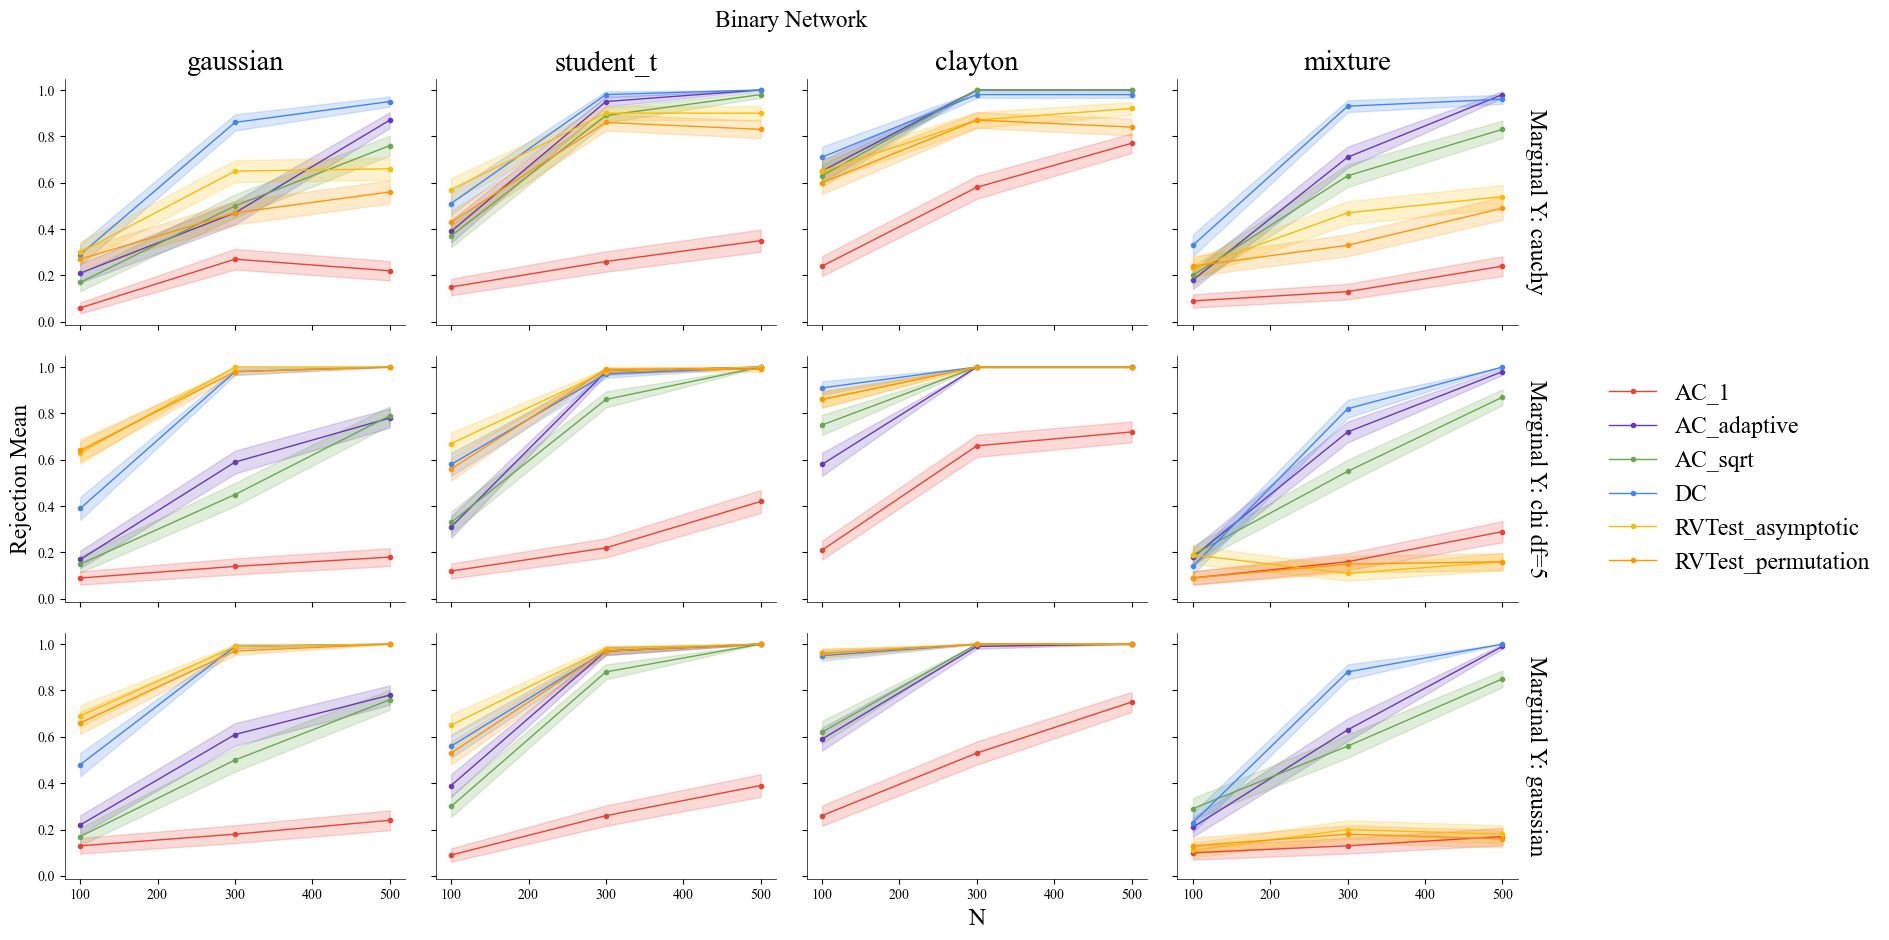

In [17]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp['copula'].isin(copulas)]
temp = temp[temp['marginal_z'].isin(marginals_z)]
temp = temp[temp['marginal_y'].isin(marginals_y)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp['n']==300],
    plotting_function=plot_scatter_markers,
    x_axis="marginal_y",
    y_axis="Rejection_mean",
    factors=["method", "copula", 'marginal_z'],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=True,
    title="Binary Network, n=500",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=marginals_y,
    col_order=copulas,
)

plot_grid(
    grouped_stats=temp[temp['marginal_z']=='gaussian'],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "copula", "marginal_y"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
    col_order=copulas,
)

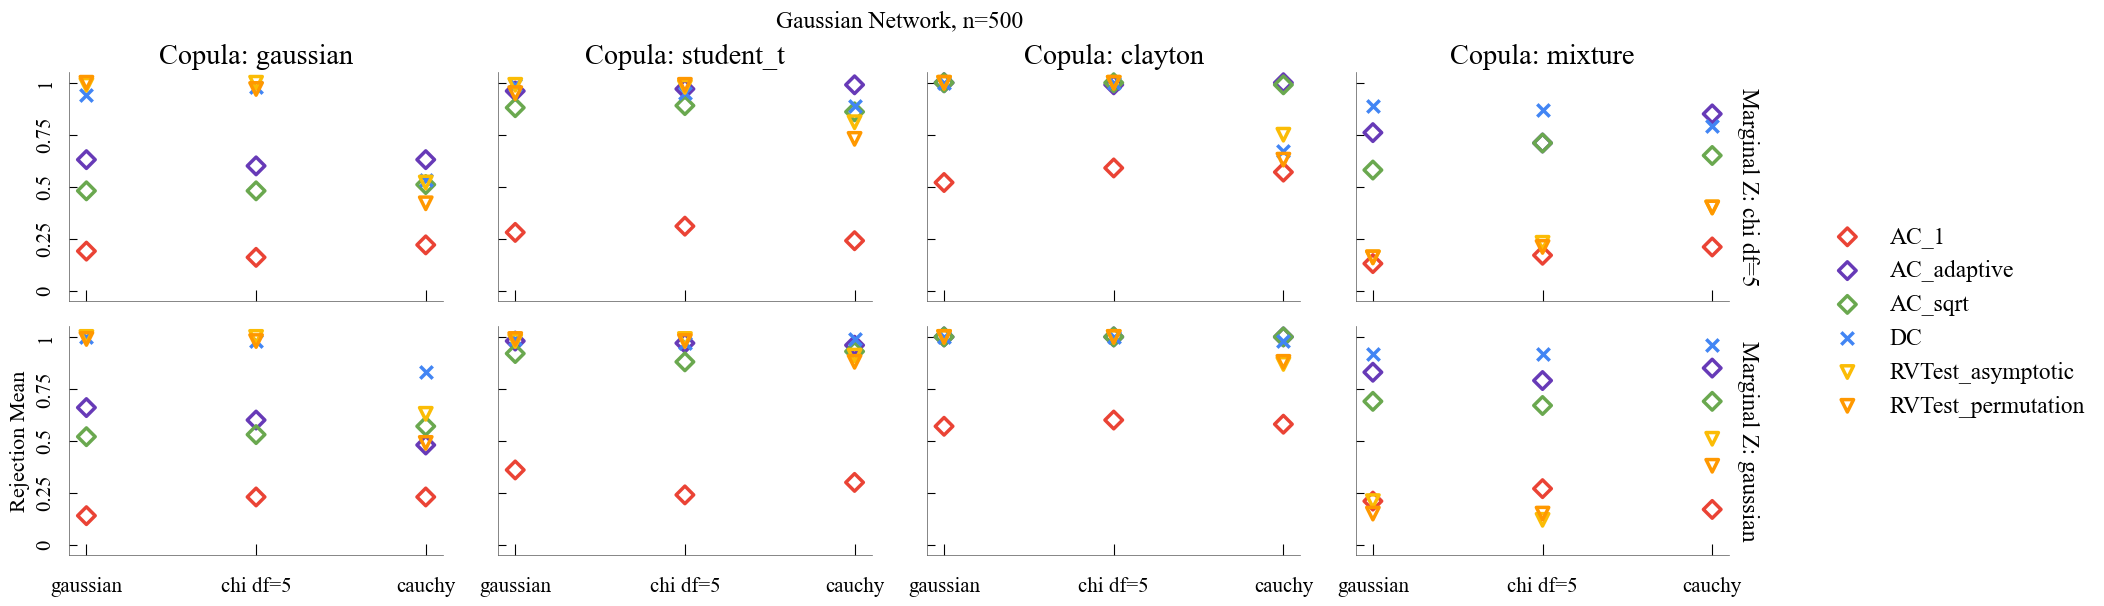

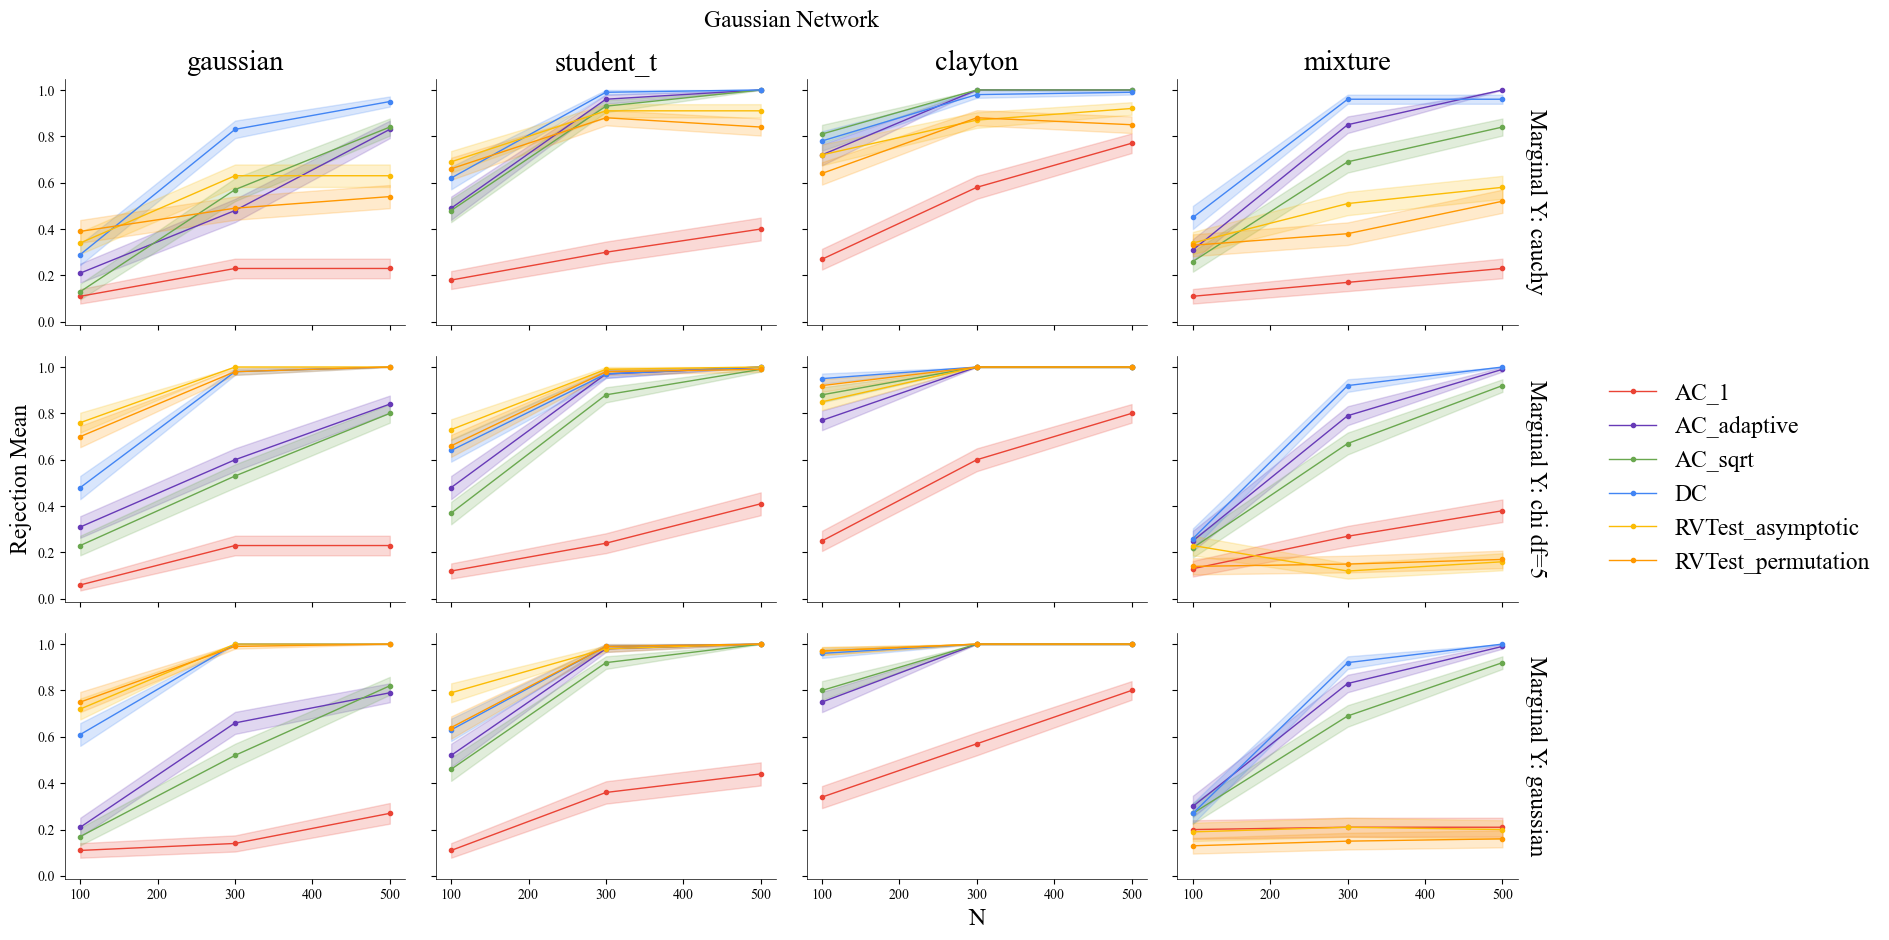

In [18]:
temp = agg_alt_gaussian.copy()
temp = temp[temp['copula'].isin(copulas)]
temp = temp[temp['marginal_z'].isin(marginals_z)]
temp = temp[temp['marginal_y'].isin(marginals_y)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp['n']==300],
    plotting_function=plot_scatter_markers,
    x_axis="marginal_y",
    y_axis="Rejection_mean",
    factors=["method", "copula", 'marginal_z'],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=True,
    title="Gaussian Network, n=500",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=marginals_y,
    col_order=copulas,
)

plot_grid(
    grouped_stats=temp[temp['marginal_z']=='gaussian'],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "copula", "marginal_y"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Gaussian Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
    col_order=copulas,
)

In [19]:
all_sim = [
    "linear",
    "exponential",
    "cubic",
    "step",
    "circle",
    "ellipse",
    "spiral",
    "quadratic",
    "fourth_root",
    "log",
    "w_shaped",
    "two_parabolas",
    "bernoulli",
    "square",
    "diamond",
    "sin_sixteen_pi",
]

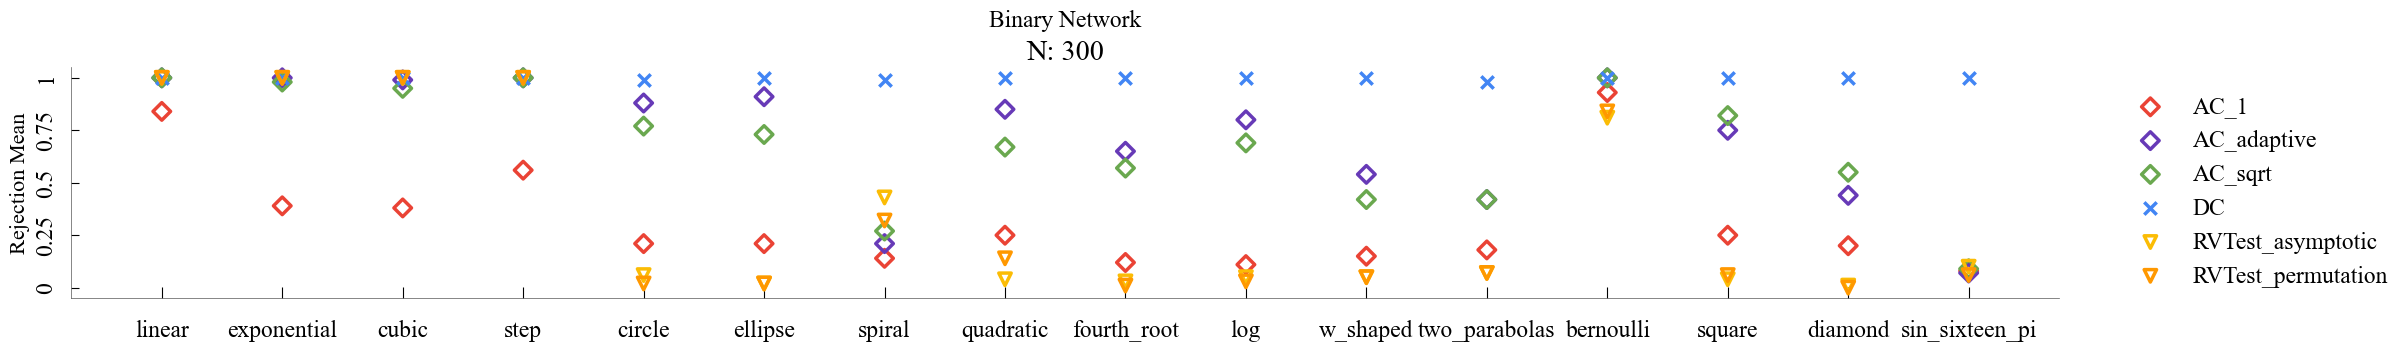

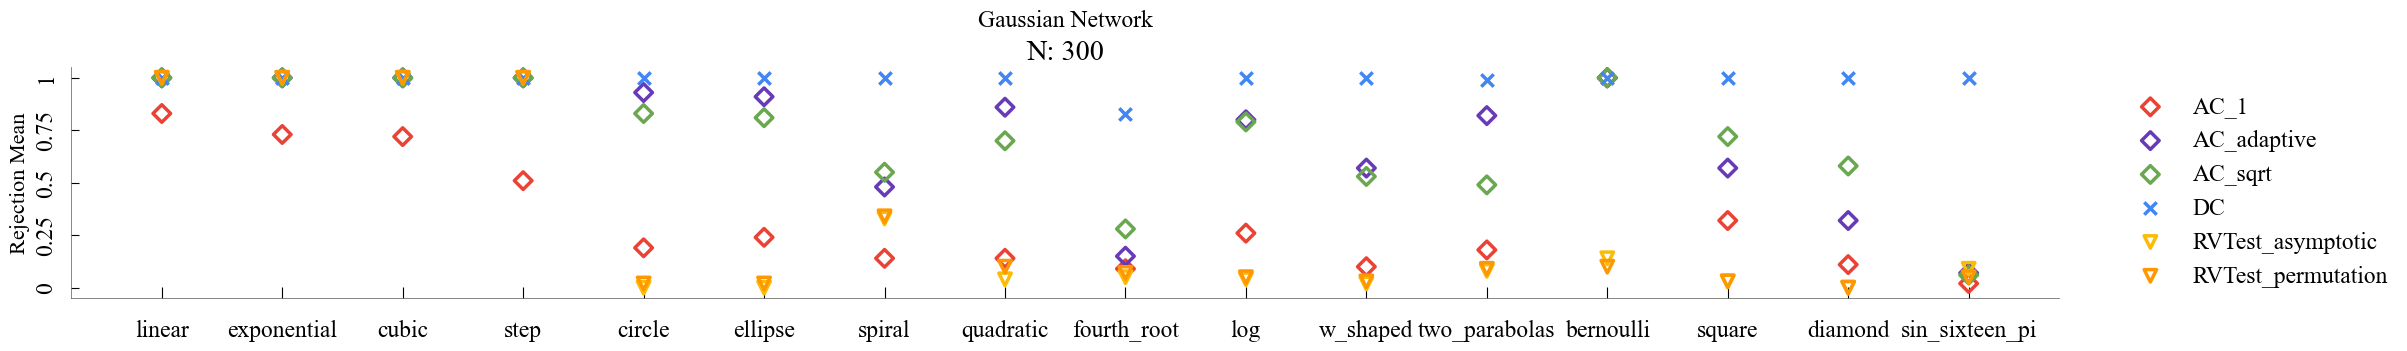

In [20]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp['latent_sim'].isin(all_sim)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 300],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_sim,
    show_x_axis_title=False,
    x_tick_labelsize=17,
    y_tick_labelsize=17,
    x_tick_rotation=0,
    title="Binary Network",
)

temp = agg_alt_gaussian.copy()
temp = temp[temp['latent_sim'].isin(all_sim)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 300],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_sim,
    show_x_axis_title=False,
    x_tick_labelsize=17,
    y_tick_labelsize=17,
    x_tick_rotation=0,
    title="Gaussian Network",
)

In [21]:
all_functional_forms = [
    "linear",
    "interaction",
    "pareto",
    "max",
    "abs_max",
    "radial",
    "sine",
    "tanh_product",
]

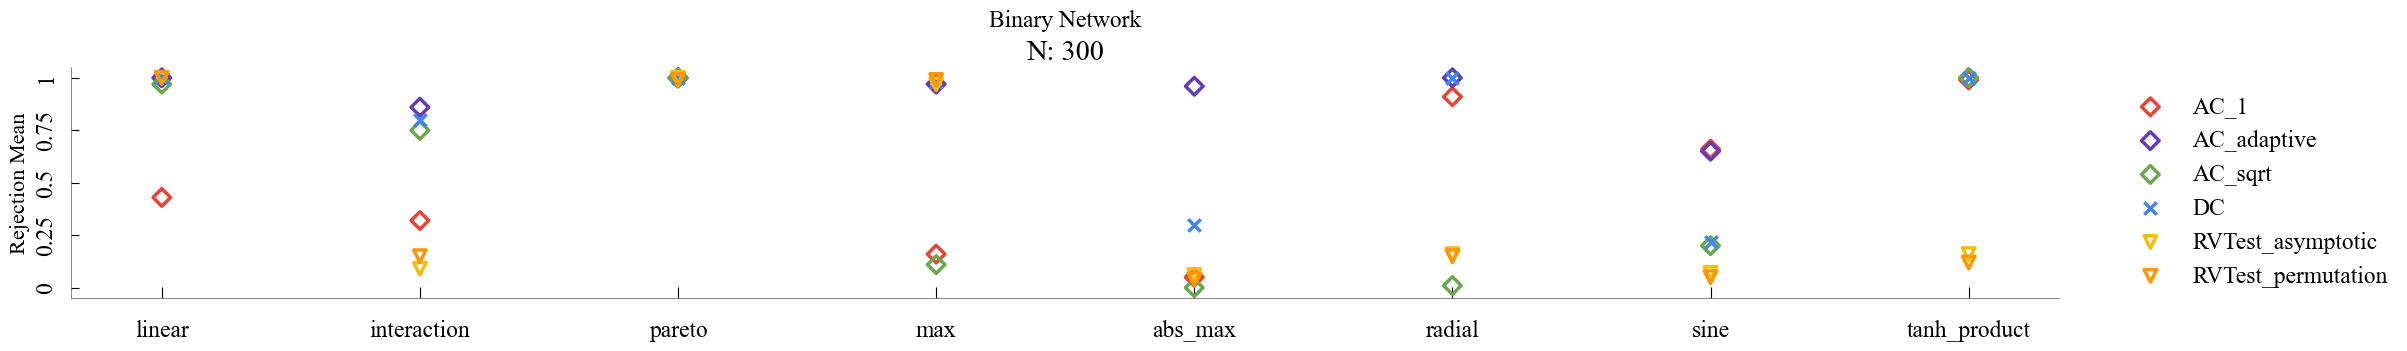

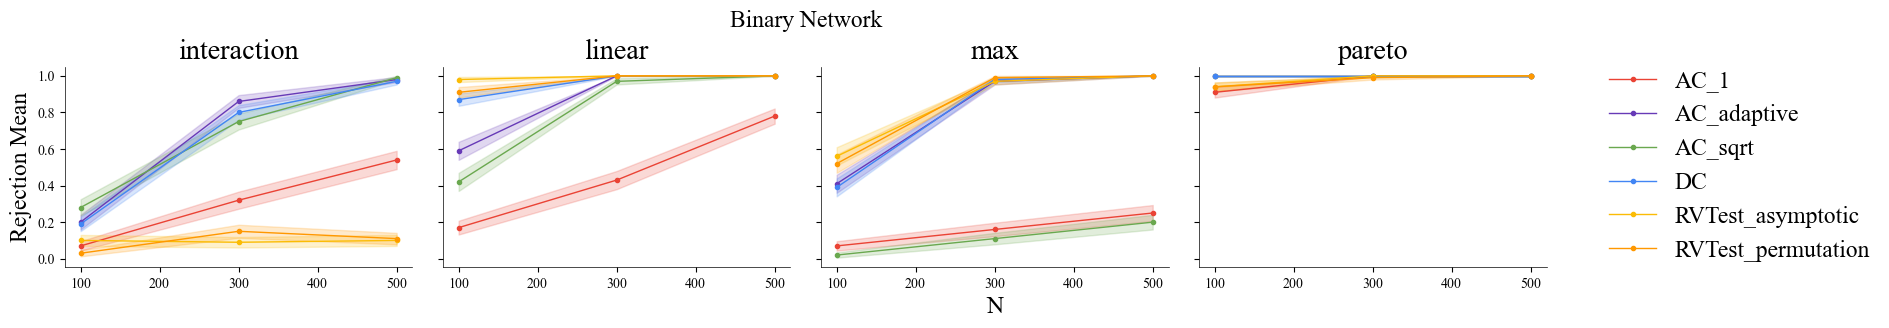

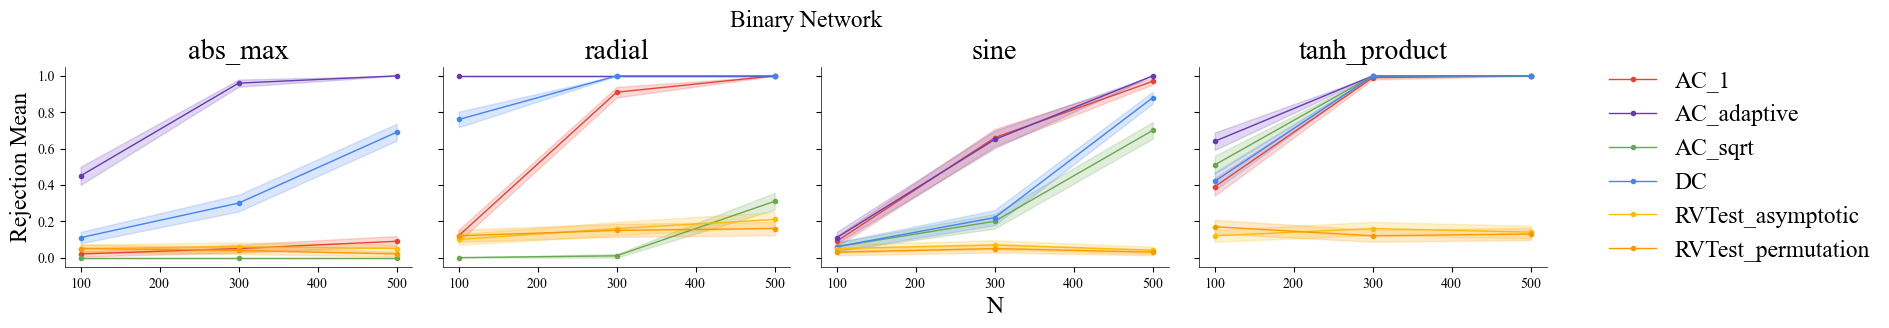

In [22]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp['functional_form'].isin(all_functional_forms)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 300],
    x_axis="functional_form",
    y_axis="Rejection_mean",
    factors=["method", "n",],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_functional_forms,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Binary Network",
)


plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[:4])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[4:])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

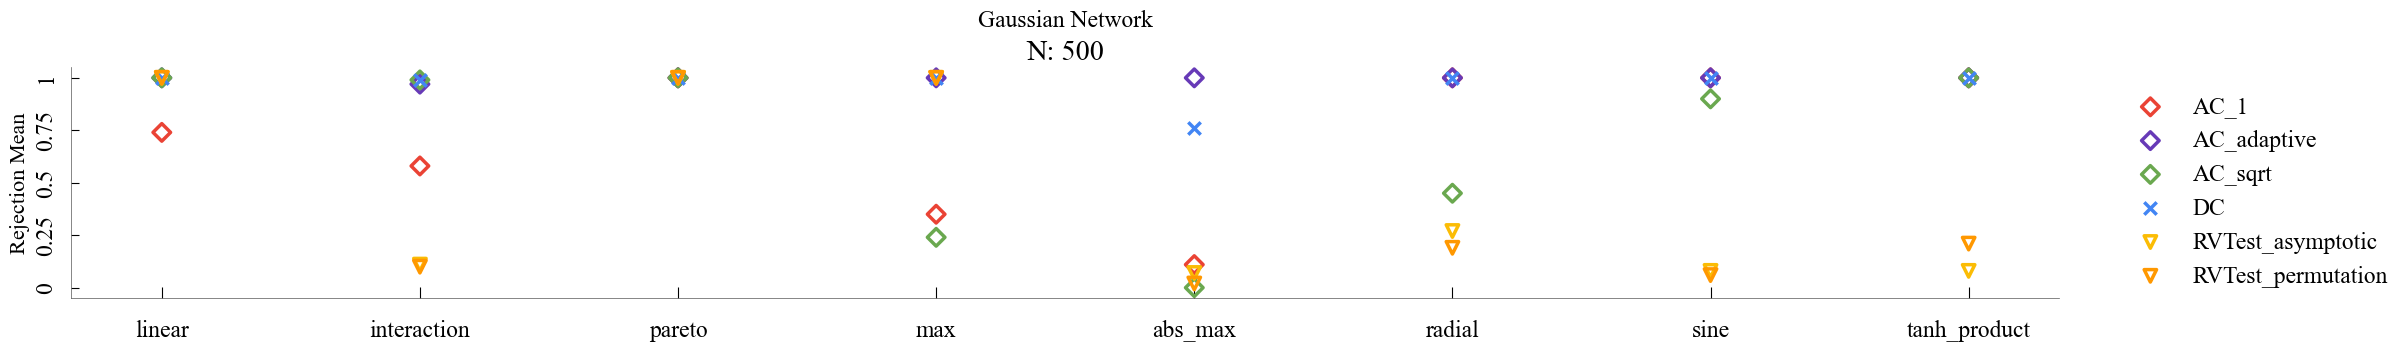

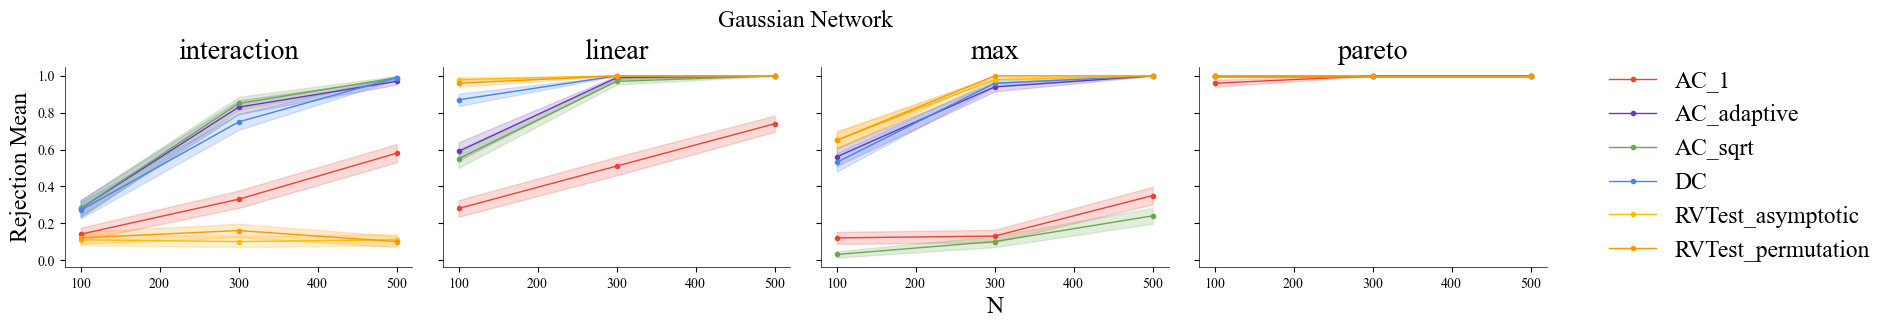

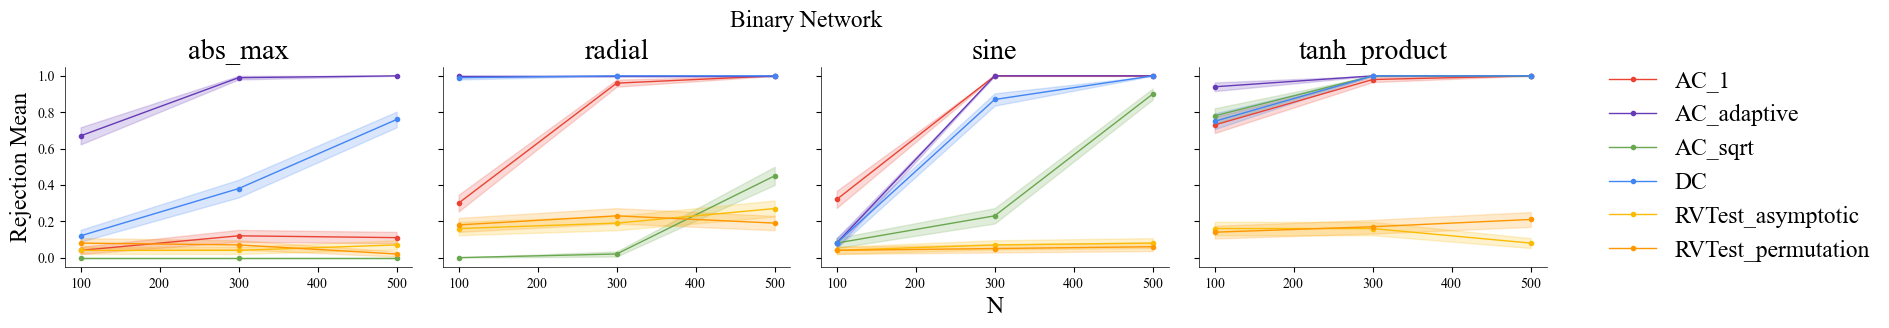

In [23]:
temp = agg_alt_gaussian.copy()
temp = temp[temp['functional_form'].isin(all_functional_forms)]
temp = temp[temp['method'].isin(colors.keys())]

plot_grid(
    grouped_stats=temp[temp["n"] == 500],
    x_axis="functional_form",
    y_axis="Rejection_mean",
    factors=["method", "n",],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_functional_forms,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Gaussian Network",
)


plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[:4])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Gaussian Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

plot_grid(
    grouped_stats=temp[temp["functional_form"].isin(all_functional_forms[4:])],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "functional_form"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    colors=colors,
    show_row_titles=True,
    show_col_names=False,
)

In [24]:
# all_sbm = ['step', 'softmax']

# temp = agg_alt_bernoulli.copy()
# temp = temp[temp['sbm_covariate_sampling'].isin(all_sbm)]
# temp = temp[temp['method'].isin(colors.keys())]

# plot_grid(
#     grouped_stats=temp[temp["n"] == 500],
#     x_axis="sbm_covariate_sampling",
#     y_axis="Rejection_mean",
#     factors=["method", "x_distribution", 'assortativity'],
#     plotting_function=plot_scatter_markers,
#     colors=colors,
#     markers=marker_map,
#     height=2.5,
#     aspect=1.5,
#     add_legend=True,
#     x_order=all_sbm,
#     show_x_axis_title=False,
#     show_col_names=False,
#     x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=17,  # ← same for y (optional)
#     x_tick_rotation=0,
#     title="Binary Network",
# )

# plot_grid(
#     grouped_stats=temp[temp['sbm_covariate_sampling'].isin(all_sbm[1:])],
#     plotting_function=plot_with_bands,
#     x_axis="n",
#     y_axis="Rejection_mean",
#     factors=["method", "assortativity", "x_distribution"],
#     height=2.5,
#     se_bands="Rejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Gaussian Network",
#     colors=colors,
#     show_row_titles=True,
#     show_col_names=False,
# )

In [25]:
# all_sbm = ['step', 'softmax']

# temp = agg_alt_gaussian.copy()
# temp = temp[temp['sbm_covariate_sampling'].isin(all_sbm)]
# temp = temp[temp['method'].isin(colors.keys())]

# plot_grid(
#     grouped_stats=temp[temp["n"] == 500],
#     x_axis="sbm_covariate_sampling",
#     y_axis="Rejection_mean",
#     factors=["method", "x_distribution", 'assortativity'],
#     plotting_function=plot_scatter_markers,
#     colors=colors,
#     markers=marker_map,
#     height=2.5,
#     aspect=1.5,
#     add_legend=True,
#     x_order=all_sbm,
#     show_x_axis_title=False,
#     show_col_names=False,
#     x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
#     y_tick_labelsize=17,  # ← same for y (optional)
#     x_tick_rotation=0,
#     title="Gaussian Network",
# )

# # plot_grid(
# #     grouped_stats=temp[temp['sbm_covariate_sampling'].isin(all_sbm[:1])],
# #     plotting_function=plot_with_bands,
# #     x_axis="n",
# #     y_axis="Rejection_mean",
# #     factors=["method", "assortativity", "x_distribution"],
# #     height=3,
# #     se_bands="Rejection_sem",
# #     share_x=True,
# #     share_y=True,
# #     title="Gaussian Network",
# #     colors=colors,
# #     show_row_titles=True,
# #     show_col_names=False,
# # )

# plot_grid(
#     grouped_stats=temp[temp['sbm_covariate_sampling'].isin(all_sbm[1:])],
#     plotting_function=plot_with_bands,
#     x_axis="n",
#     y_axis="Rejection_mean",
#     factors=["method", "assortativity", "x_distribution"],
#     height=3,
#     se_bands="Rejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Gaussian Network",
#     colors=colors,
#     show_row_titles=True,
#     show_col_names=False,
# )